# Savitzky-Golay State Estimator — Test Notebook
Test the `StateEstimator` filter on synthetic distance / angle signals with adjustable Gaussian noise.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from state_estimator import StateEstimator

## Parameters
Adjust simulation length, time step, ground-truth velocities, and noise levels here.

In [17]:
# ── simulation parameters ──
n_samples = 6000
dt        = 1.0/2000.0           # seconds

# ground-truth square-wave velocity amplitudes
v_amp      = 1.5            # m/s   peak linear velocity
omega_amp  = 2.0            # rad/s peak angular velocity

# square-wave periods (seconds)
v_period     = 1.0          # linear velocity toggles every half-period
omega_period = 2.0          # angular velocity toggles every half-period

# noise standard deviations (adjust these)
noise_dist  = 0.0001         # metres
noise_theta = 0.0001         # radians

# filter parameters
sg_order       = 2
sg_window_size = 11
cutoff_freq    = 200.0        # Hz – EMA cutoff for position smoothing

## Generate ground-truth signals and noisy measurements

In [18]:
np.random.seed(42)

t = np.arange(n_samples) * dt   

# ground-truth square-wave velocities
# np.sign(sin(...)) gives +1 / -1 square wave
vel_true_arr   = v_amp     * np.sign(np.sin(2 * np.pi * t / v_period))
omega_true_arr = omega_amp * np.sign(np.sin(2 * np.pi * t / omega_period))

# integrate velocities to get ground-truth positions
dist_true  = np.cumsum(vel_true_arr)   * dt
theta_true = np.cumsum(omega_true_arr) * dt

# noisy measurements
dist_meas  = dist_true  + np.random.normal(0, noise_dist,  n_samples)
theta_meas = theta_true + np.random.normal(0, noise_theta, n_samples)

## Run the Savitzky-Golay filter

In [19]:
estimator = StateEstimator(order=sg_order, window_size=sg_window_size, dt=dt, cutoff_freq=cutoff_freq)

dist_est  = np.zeros(n_samples)
theta_est = np.zeros(n_samples)
vel_est   = np.zeros(n_samples)
omega_est = np.zeros(n_samples)

for i in range(n_samples):
    d, th, v, om = estimator.step(dist_meas[i], theta_meas[i])
    dist_est[i]  = d
    theta_est[i] = th
    vel_est[i]   = v
    omega_est[i] = om

print(f"EMA alpha = {estimator.alpha:.6f}  (cutoff = {cutoff_freq} Hz)")
print(f"filter settled after {sg_window_size} samples ({sg_window_size*dt:.3f} s)")

[ 258.74125874   67.13286713  -77.85547786 -176.22377622 -227.97202797
 -233.1002331  -191.60839161 -103.4965035    31.23543124  212.58741259
  440.55944056]
EMA alpha = 0.385870  (cutoff = 200.0 Hz)
filter settled after 11 samples (0.005 s)


## Results — 4 plots
1. **Distance** — ground truth vs measured vs denoised  
2. **Theta** — ground truth vs measured vs denoised  
3. **Linear velocity** — ground truth vs numerical diff of measured vs filter estimate  
4. **Angular velocity** — ground truth vs numerical diff of measured vs filter estimate

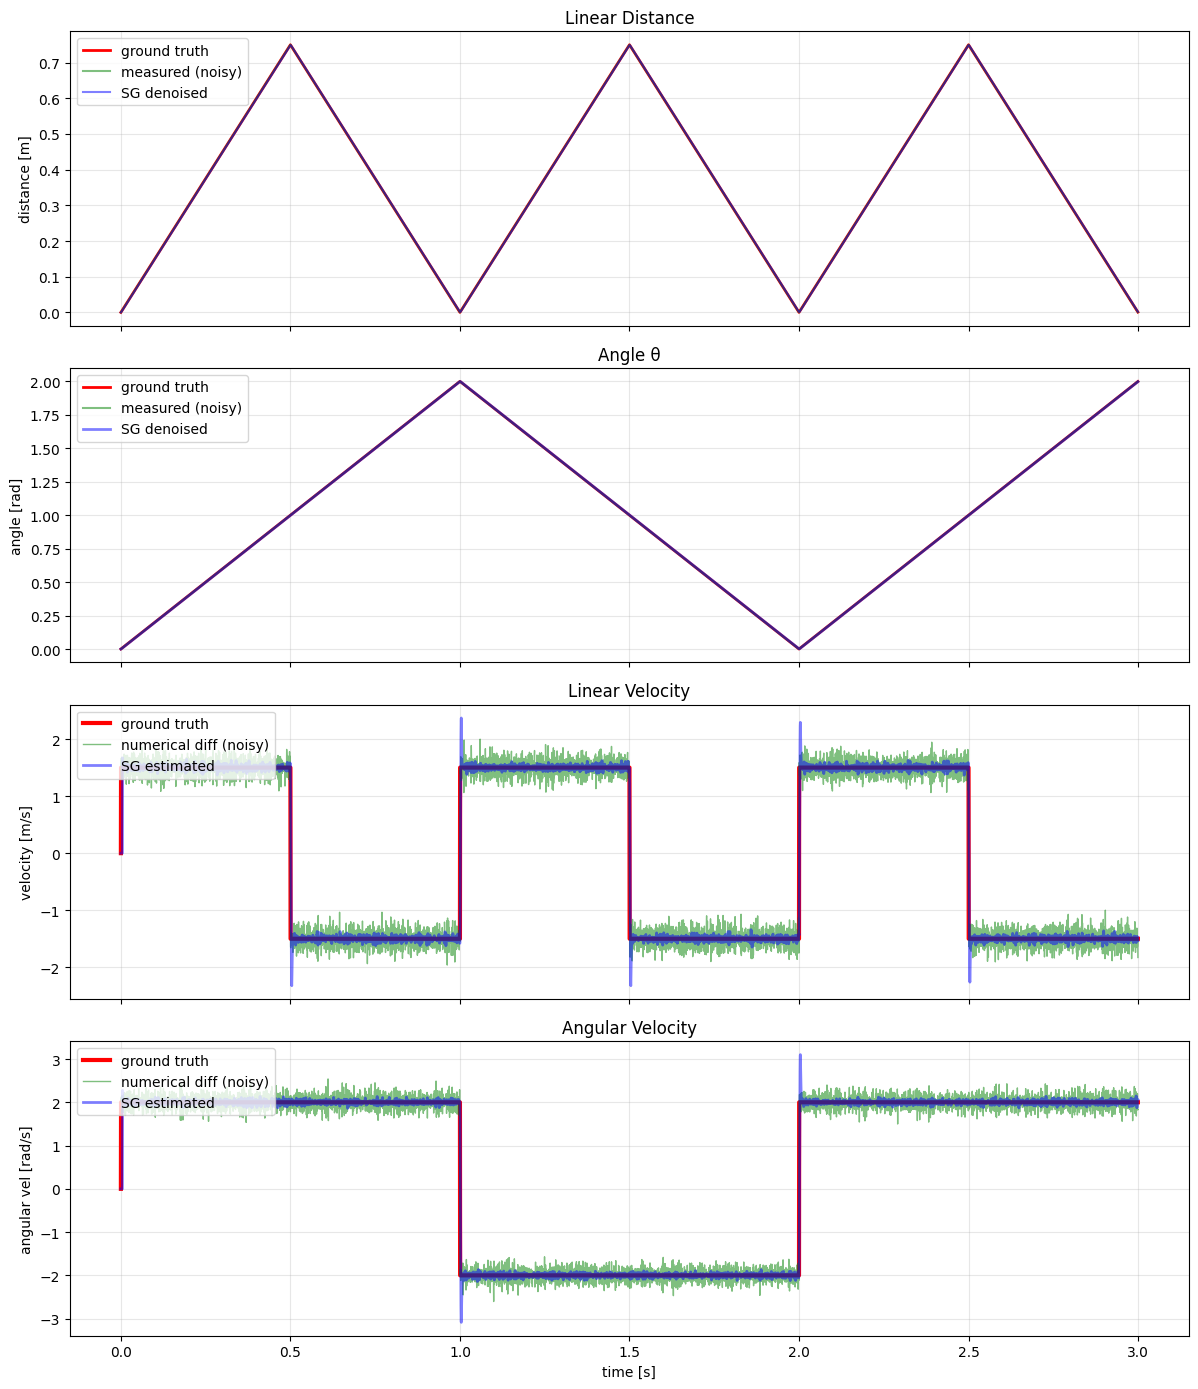

In [20]:
# numerical derivative of raw measurements (for comparison)
vel_meas_num   = np.gradient(dist_meas,  dt)
omega_meas_num = np.gradient(theta_meas, dt)

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# ── 1. Distance ──
ax = axes[0]
ax.plot(t, dist_true,  'red',  linewidth=2.0, alpha=1.0, label='ground truth')
ax.plot(t, dist_meas,  'green',  markersize=1.0, alpha=0.5, label='measured (noisy)')
ax.plot(t, dist_est,   'blue',  linewidth=1.5,alpha=0.5, label='SG denoised')
ax.set_ylabel('distance [m]')
ax.set_title('Linear Distance')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# ── 2. Theta ──
ax = axes[1]
ax.plot(t, theta_true,  'red',  linewidth=2.0, alpha=1.0, label='ground truth')
ax.plot(t, theta_meas,  'green',  markersize=1.0, alpha=0.5, label='measured (noisy)')
ax.plot(t, theta_est,   'blue',  linewidth=2.0, alpha=0.5, label='SG denoised')
ax.set_ylabel('angle [rad]')
ax.set_title('Angle θ')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# ── 3. Linear velocity ──
ax = axes[2]
ax.plot(t, vel_true_arr,  'red',  linewidth=3.0, alpha=1.0,label='ground truth')
ax.plot(t, vel_meas_num,  'green',  linewidth=1.0, alpha=0.5, label='numerical diff (noisy)')
ax.plot(t, vel_est,       'blue',  linewidth=2.0, alpha=0.5,label='SG estimated')
ax.set_ylabel('velocity [m/s]')
ax.set_title('Linear Velocity')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# ── 4. Angular velocity ──
ax = axes[3]
ax.plot(t, omega_true_arr,  'red',  linewidth=3.0, alpha=1.0, label='ground truth')
ax.plot(t, omega_meas_num,  'green',  linewidth=1.0, alpha=0.5, label='numerical diff (noisy)')
ax.plot(t, omega_est,       'blue',  linewidth=2.0, alpha=0.5, label='SG estimated')
ax.set_ylabel('angular vel [rad/s]')
ax.set_title('Angular Velocity')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

ax.set_xlabel('time [s]')

plt.tight_layout()
plt.savefig("estimator_test_results.png", dpi=150)
plt.show()